# Multi-Agent Multi-Armed Bandits: 
## application to EVs smart charging with grid constraints

In [3]:
from matplotlib import pyplot as plt
from simulation.simulation import *
from utils.plot_analysis import *
from strategies import *
from utils.strategy_comparison import *
from tqdm.notebook import tqdm
import pickle
import os

# Define the path to the results
# base_path = "test_results_120ev_80nf_1200area_1000ep_limit/"
Strategy.register("FTPL-IRS-EXP", MABFTPL)
Strategy.register("FTPL-IRS-F2", MABFTPL)
Strategy.register("Inde-TS", MABTS)
Strategy.register("FTPL-IRS", MABFTPL)
Strategy.register("GREEDY", Baseline)
Strategy.register("EV_DRL", DRL)
# add drl

# Base directory for this experiment
BASE_PATH = "./results_ECML2026_30EVs_DRL_setup6_2000eps_test/"
strategies_and_samples_dict = find_strategies_and_samples(BASE_PATH, verbose=True)

Strategies and samples found:
  - CA: 1
  - default: 1
  - images: 3
  - tables: 2


## Load all results

In [4]:
# Subdirectories
RESULT_PATH = os.path.join(BASE_PATH, "CA")
SAVE_PATH   = os.path.join(BASE_PATH, "images", "CA")
TABLE_PATH = os.path.join(BASE_PATH, "tables")
# Ensure all required directories exist
for path in [BASE_PATH, RESULT_PATH, SAVE_PATH,TABLE_PATH]:
    os.makedirs(path, exist_ok=True)

./results_ECML2026_30EVs_DRL_setup6_2000eps_test/CA\EVs_30/
Strategies and samples found:
  - DQN: 1
  - FTPL-IRS-EXP: 1
  - GREEDY: 1


Strategies (N=30): 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:04<00:00,  1.57s/it]


Saved: ./results_ECML2026_30EVs_DRL_setup6_2000eps_test/images\CA\agent0_cumloss_N30_ep0_5000_mean_std.pdf


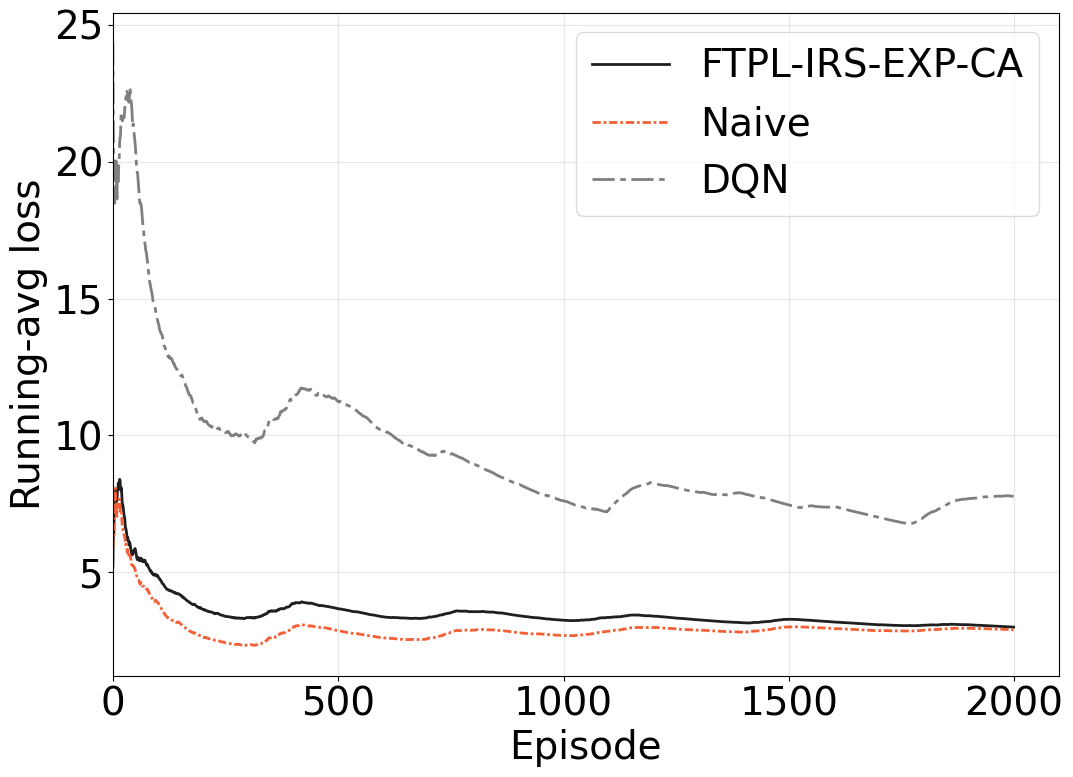

In [5]:
cmp = StrategyComparison(
    path=RESULT_PATH,  # or whatever root contains EVs_{N}/
    n_agents=30,
    verbose=True,
)


fig, ax = cmp.plot_agent_cumulative_loss_from_disk(
    ev_id=0,                 # which agent to plot
    episode_start=0,
    episode_end=5000,
    cumulative_mode="mean",  # running average of cumulative sum
    band="std",              # "std" or "minmax"
    save_path=SAVE_PATH,
    figsize=(11,8),
     legend_fontsize=28,
    tick_fontsize=28,
    axis_label_fontsize=28,
    ylim = 12.5,
    verbose = True
)


Skip

In [6]:
num_ev_agents = [30]
computation_table = [num_ev_agents, []]

for n in num_ev_agents:
    sc = StrategyComparison(path=RESULT_PATH, n_agents=n, verbose=False)
    table = sc.compute_time_table_from_disk()
    computation_table[1].append(table)

with open(BASE_PATH+"tables/computation_table.pkl", "wb") as f:
    pickle.dump(computation_table, f)


Strategies (N=30): 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:03<00:00,  1.33s/it]


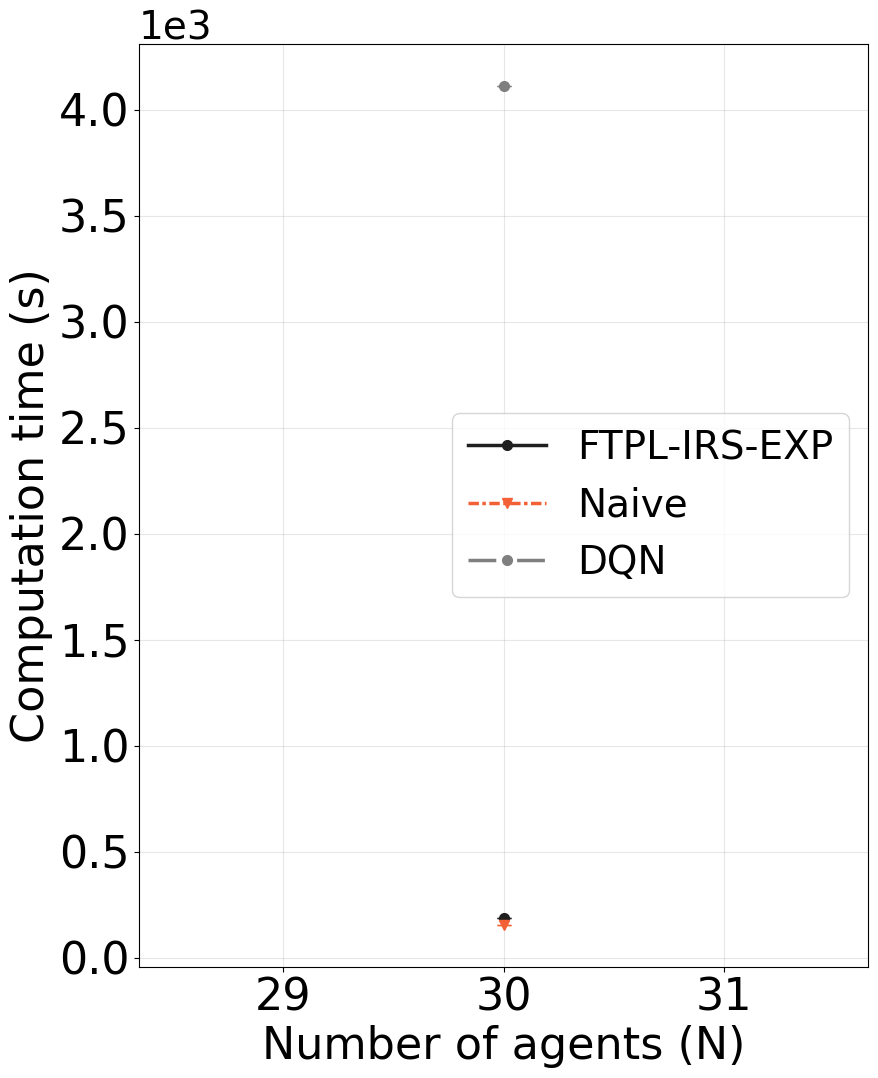

In [7]:
sc = StrategyComparison(path=RESULT_PATH, n_agents=30, verbose=False)  # n_agents here doesn't matter for plotting pickle
full_df = sc.plot_mean_computation_time_vs_N_from_pickle(
    pkl_path=BASE_PATH+"tables/computation_table.pkl",
    loglog=False,
    save_path=BASE_PATH+"images"+"/mean_time_vs_N_minmax.pdf",
    figsize=(9,11),
    linewidth=2.5
    , legend_fontsize=28,
    tick_fontsize=32,
    axis_label_fontsize=32,
)

### Strategy Results Organization

For these functions, place all the strategy results you want to compare in a new **FULL** folder.

Each strategy variant must use a **different folder name** for each variants, for example:

FTPL-IRS-F2 for the default loss mode training, FTPL-IRS-F2-CA for the congestion_aware loss mode training

./results_ECML2026_30EVs_DRL_setup6_2000eps_test/CA\EVs_30/
Strategies and samples found:
  - DQN: 1
  - FTPL-IRS-EXP: 1
  - GREEDY: 1


Strategies (N=30): 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:03<00:00,  1.32s/it]


Saved: ./results_ECML2026_30EVs_DRL_setup6_2000eps_test/images\CA\congestion_frequency_N30_days0_2000_roll20_stdband.pdf


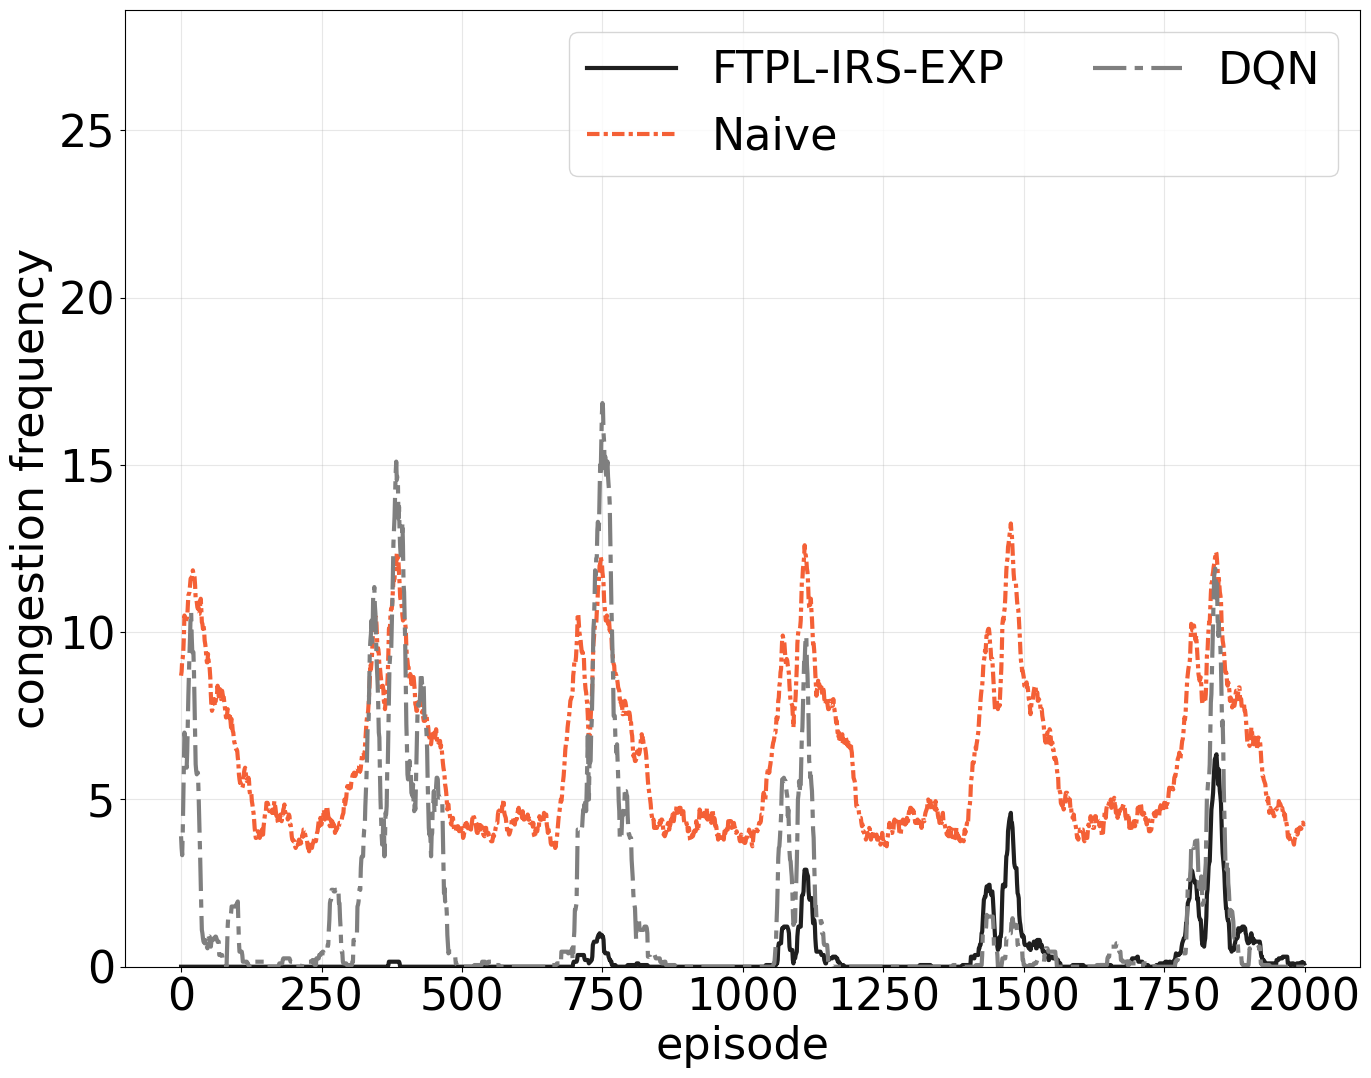

(<Figure size 1400x1100 with 1 Axes>,
 <Axes: xlabel='episode', ylabel='congestion frequency'>)

In [8]:
cmp = StrategyComparison(
    path=RESULT_PATH,  # or whatever root contains EVs_{N}/ # FULL to CA
    n_agents=30,
    verbose=True,
    
)

cmp.plot_congestion_frequency_from_disk(window_size=20,legend_fontsize=32,
    tick_fontsize=32,
    axis_label_fontsize=32,
    figsize=(14,11),
    save_path=SAVE_PATH)

In [9]:
cmp = StrategyComparison(
    path=RESULT_PATH,
    n_agents=30,
    verbose=True,
)

import os, gc
import numpy as np



df = cmp.compute_old_metrics_scientific_table_from_disk(
    naive_strategy="GREEDY",
    optimal_strategy="MILP_Price_Forecast",
    price_day_start=0,
    price_day_end=None,
    cong_day_start=0,
    cong_day_end=1459,
    save_dir=TABLE_PATH,
    filename="disk_scientific_5metrics.pkl",
)

display(df)


./results_ECML2026_30EVs_DRL_setup6_2000eps_test/CA\EVs_30/
Strategies and samples found:
  - DQN: 1
  - FTPL-IRS-EXP: 1
  - GREEDY: 1


Strategies (N=30): 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:03<00:00,  1.32s/it]


Saved: ./results_ECML2026_30EVs_DRL_setup6_2000eps_test/tables\disk_scientific_5metrics.pkl


,Strategy,N_agents,Price_final_norm (mean),Price_final_norm (std),Price_n_seeds,Total_congestive_instants (mean),Total_congestive_instants (std),Congestion_n_seeds,Avg_disconnections_per_agent (mean),Avg_disconnections_per_agent (std),Disconnections_n_seeds,Regret_price_vs_Naive (mean),Regret_price_vs_Naive (std),Regret_price_vs_Naive (n),Regret_price_vs_ILP-PF (mean),Regret_price_vs_ILP-PF (std),Regret_price_vs_ILP-PF (n)
0,FTPL-IRS-EXP-CA,30,11.546070,0.0,1,202.0,0.0,1,14.433333,0.0,1,-0.935193,0.0,1,NaN,NaN,0
1,Naive,30,12.481263,0.0,1,8857.0,0.0,1,1634.300000,0.0,1,0.000000,0.0,1,NaN,NaN,0
2,DQN,30,26.845223,0.0,1,2768.0,0.0,1,202.366667,0.0,1,14.363960,0.0,1,NaN,NaN,0


./results_ECML2026_30EVs_DRL_setup6_2000eps_test/CA\EVs_30/
Strategies and samples found:
  - DQN: 1
  - FTPL-IRS-EXP: 1
  - GREEDY: 1


Strategies (N=30): 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:03<00:00,  1.31s/it]


Saved: ./results_ECML2026_30EVs_DRL_setup6_2000eps_test/images\CA\final_soc_gap_N30_ep0_5000_agentdist_q10_q90.pdf


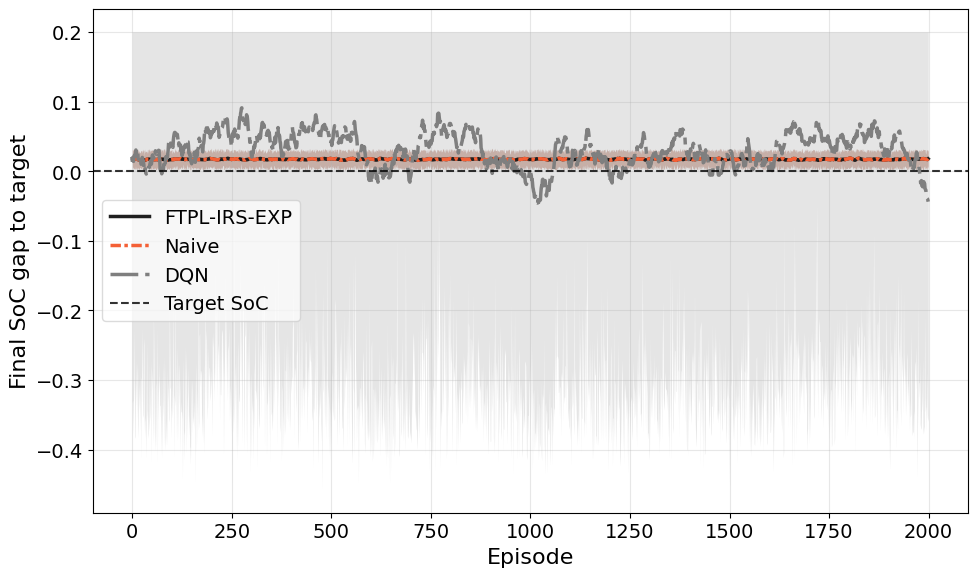

(<Figure size 1000x600 with 1 Axes>,
 <Axes: xlabel='Episode', ylabel='Final SoC gap to target'>)

In [10]:
cmp = StrategyComparison(
    path=RESULT_PATH,
    n_agents=30,
    verbose=True,
)

cmp.plot_final_soc_gap_from_disk(
    episode_start=0,
    episode_end=5000,
    window_size=10,
    band="quantile",
    aggregate_agents=False,
    save_path=SAVE_PATH
)